### Imports and PENet module resgitration in ultralytics

In [ ]:
from penet_original import PENetWrapper
import ultralytics.nn.tasks as _t
import ultralytics.nn.modules as _m
_t.__dict__['PENetWrapper'] = PENetWrapper
_m.__dict__['PENetWrapper'] = PENetWrapper

import torch, copy
from ultralytics import YOLO
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

### YOLO V8 yaml config, Loading coco-trained weights

In [ ]:
model = YOLO('pe_yolov8n.yaml')
model.model.to('cuda')
pre = YOLO('yolov8n.pt')
pre_sd = pre.model.state_dict()
mod_sd = model.model.state_dict()
shifted = {}
for k, v in pre_sd.items():
    if k.startswith('model.') and k.split('.')[1].isdigit():
        nk = 'model.' + str(int(k.split('.')[1])+1) + '.' + '.'.join(k.split('.')[2:])
        if nk in mod_sd and mod_sd[nk].shape == v.shape:
            shifted[nk] = v
model.model.load_state_dict(shifted, strict=False)
print(f'Loaded {len(shifted)} pretrained backbone weights')

enh = sum(p.numel() for p in model.model.model[0].parameters())
tot = sum(p.numel() for p in model.model.parameters())
print(f'Enhanced Author PENet Parameters: {enh:,} ({100*enh/tot:.2f}%)  Total: {tot:,}')

torch.save({
    'model': copy.deepcopy(model.model).half(),
    'train_args': {'task':'detect','data':'/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml','imgsz':640,'model':'pe_yolov8n.yaml'},
}, 'penet_orig_v8n_init_1.pt')
print('Ready. Proceed to Stage 1.')

Loaded 319 pretrained backbone weights
Enhanced Author PENet Parameters: 93,925 (3.02%)  Total: 3,107,113
Ready. Proceed to Stage 1.


### Stage 1 Training

In [ ]:
# Cell 2: Two-Stage Training (Stage 1)
from penet_original import PENetWrapper
import ultralytics.nn.tasks as _t
import ultralytics.nn.modules as _m
_t.__dict__['PENetWrapper'] = PENetWrapper
_m.__dict__['PENetWrapper'] = PENetWrapper

from ultralytics import YOLO
model = YOLO('penet_orig_v8n_init_1.pt')

yolo_layers = [i for i in range(1, 23)]

print('\n--- STARTING STAGE 1: Freezing YOLO (30 Epochs) ---')
model.info()



--- STARTING STAGE 1: Freezing YOLO (30 Epochs) ---
pe_YOLOv8n summary: 240 layers, 3,107,113 parameters, 3,107,022 gradients


(240, 3107113, 3107022, 0.0)

In [ ]:
model.train(
    data='/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml',
    epochs=20, imgsz=640, batch=64,
    optimizer='SGD', lr0=0.01, lrf=0.01, cos_lr=True, momentum=0.937,
    warmup_epochs=3, weight_decay=5e-4, workers=32, cache='ram', amp=True,
    patience=30, mosaic=1.0, close_mosaic=0, mixup=0.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.6,
    translate=0.1, scale=0.2, fliplr=0.5, erasing=0.0,
    project='runs/ver4.1', name='stage1', exist_ok=True, plots=True, save=True,freeze=yolo_layers
)

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/20      37.6G      2.318      4.352      2.201        343        640: 100% ━━━━━━━━━━━━ 47/47 2.1s/it 1:401.9sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.0it/s 7.7s0.5s
                   all       1798       6204     0.0405      0.274     0.0537      0.032

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/20      37.8G      1.671      2.968      1.637        335        640: 100% ━━━━━━━━━━━━ 47/47 1.9s/it 1:311.9sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.0it/s 7.7s0.6s
                   all       1798       6204       0.62      0.206      0.314      0.185

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      19/20      37.7G      1.338      1.409      1.372        275        640: 100% ━━━━━━━━━━━━ 47/47 1.9s/it 1:311.9sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.2it/s 6.7s0.5s
                   all       1798       6204      0.743      0.599      0.684      0.438

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      20/20      37.7G       1.33      1.389      1.361        314        640: 100% ━━━━━━━━━━━━ 47/47 1.9s/it 1:311.9sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.2it/s 6.7s0.5s
                   all       1798       6204      0.745      0.598      0.686      0.438

20 epochs completed in 0.550 hours.
Optimizer stripped from /home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage1/weights/last.pt, 15.8MB
Optimizer stripped from /home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage1/weights/best.pt, 15.8MB

Validating /home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage1/weights/best.pt...
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
pe_YOLOv8n summary (fused): 183 layers, 3,101,913 parameters, 0 gradients
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.6it/s 9.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7969f6a36a80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

### Stage 2 Training

In [ ]:

from ultralytics import YOLO

model_stage2 = YOLO('runs/detect/runs/ver4.1/stage1/weights/best.pt')
print('\n--- STARTING STAGE 2: End to End Fine-Tuning (70 Epochs) ---')
model_stage2.train(
    data='/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml',
    epochs=40, imgsz=640, batch=32,
    optimizer='SGD', lr0=0.001,
    lrf=0.01, cos_lr=True, momentum=0.937,
    warmup_epochs=0, 
    weight_decay=5e-4, workers=16, cache='ram', amp=True,
    patience=30, mosaic=1.0, close_mosaic=0, mixup=0.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.5,
    translate=0.05, scale=0.3, fliplr=0.5, erasing=0.2, 
    project='runs/ver4.1', name='stage2', exist_ok=True, plots=True, save=True,
)


--- STARTING STAGE 2: End to End Fine-Tuning (70 Epochs) ---
New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=30

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/40      19.6G      1.389      1.501      1.398        104        640: 100% ━━━━━━━━━━━━ 94/94 1.4s/it 2:081.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.3it/s 8.8s0.3s
                   all       1798       6204      0.682      0.608      0.651      0.406

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/40      35.3G      1.336      1.392      1.352        139        640: 100% ━━━━━━━━━━━━ 94/94 1.3s/it 2:021.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.8it/s 7.5s0.3s
                   all       1798       6204        0.7        0.6      0.668      0.422

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      39/40      35.3G      1.093     0.9744      1.181        140        640: 100% ━━━━━━━━━━━━ 94/94 1.3s/it 2:031.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 4.2it/s 6.9s0.2s
                   all       1798       6204      0.771      0.633      0.724      0.466

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      40/40      35.3G      1.094     0.9706      1.185        166        640: 100% ━━━━━━━━━━━━ 94/94 1.3s/it 2:021.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.7it/s 7.8s0.3s
                   all       1798       6204      0.769      0.636      0.724      0.466

40 epochs completed in 1.444 hours.
Optimizer stripped from /home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/last.pt, 15.8MB
Optimizer stripped from /home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt, 15.8MB

Validating /home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt...
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
pe_YOLOv8n summary (fused): 183 layers, 3,101,913 parameters, 0 gradients
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.2it/s 9.1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7965cd5953a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

### Baseline model Test results

In [8]:
model=YOLO('/home/ai21ma3ai30/aaadi/yolov8n/baseline/weights/best.pt')
model.val(data='exdark.yaml',split='test')

Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3382.2±879.9 MB/s, size: 72.5 KB)
val: Scanning /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/labels/test.cache... 2562 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 1.2Git/s 0.0s
val: /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/test/2015_03019.png: ignoring corrupt image/label: Truncated File Read
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 161/161 13.7it/s 11.8s0.1s
                   all       2562       7115      0.739      0.597      0.662      0.413
               Bicycle        272        418      0.811      0.722       0.78      0.511
                  Boat        287        515      0.749      0.583      0.661      0.358
                Bottle  

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x796612dd11c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

### PENet Finetuned Model Test results

In [7]:
model=YOLO('/home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt')
model.val(data='exdark.yaml',split='test')

Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
pe_YOLOv8n summary (fused): 183 layers, 3,101,913 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2290.0±1749.2 MB/s, size: 956.3 KB)
val: Scanning /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/labels/test.cache... 2562 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 1.2Git/s 0.0s
val: /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/test/2015_03019.png: ignoring corrupt image/label: Truncated File Read
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 161/161 13.0it/s 12.4s0.1s
                   all       2562       7115      0.755      0.631      0.705       0.45
               Bicycle        272        418      0.832       0.73      0.788      0.524
                  Boat        287        515      0.783      0.645      0.735      0.407
                Bottle      

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x796b9008f410>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

### Qualitative Analysis on some sample images


image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg: 448x640 1 Dog, 2 Peoples, 165.9ms
Speed: 0.7ms preprocess, 165.9ms inference, 3.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg: 448x640 1 Dog, 2 Peoples, 20.9ms
Speed: 0.7ms preprocess, 20.9ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)


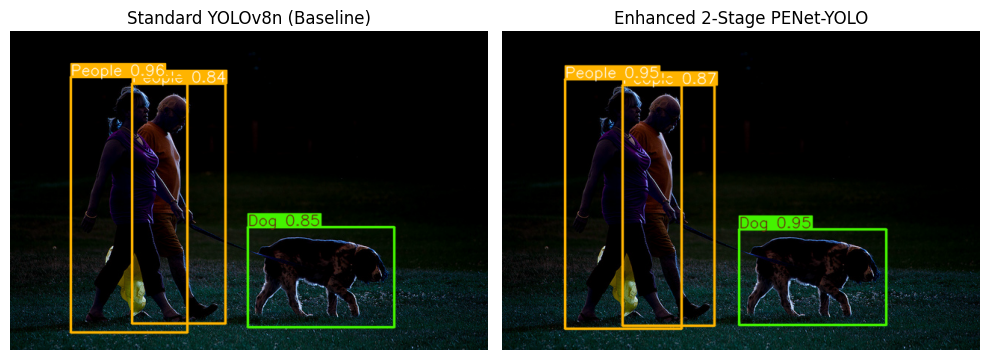

In [9]:

model = YOLO('/home/ai21ma3ai30/aaadi/penet_stage_ver2/end_to_end/weights/best.pt')
baseline=YOLO('/home/ai21ma3ai30/aaadi/runs/detect/runs/final_v8n/baseline/weights/best.pt')
results = model.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg', conf=0.40, agnostic_nms=True)
results2 = baseline.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg', conf=0.40, agnostic_nms=True)

%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(results2[0].plot())
axes[0].set_title("Standard YOLOv8n (Baseline)")
axes[0].axis('off')
axes[1].imshow(results[0].plot())
axes[1].set_title("Enhanced 2-Stage PENet-YOLO")
axes[1].axis('off')
plt.tight_layout()
plt.show()


image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg: 640x480 2 Dogs, 1 People, 96.5ms
Speed: 0.7ms preprocess, 96.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg: 640x480 1 person, 19.6ms
Speed: 0.7ms preprocess, 19.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)


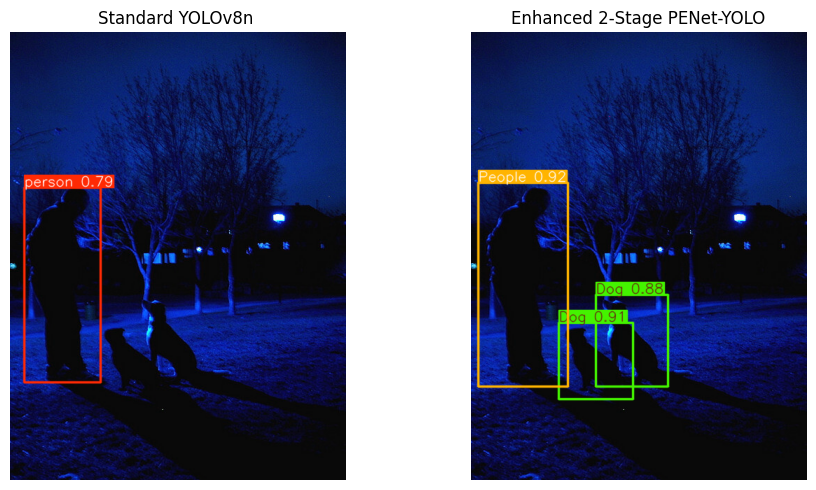

In [5]:


model = YOLO('/home/ai21ma3ai30/aaadi/runs/detect/runs/penet_stage2/end_to_end/weights/best.pt')
baseline=YOLO('yolov8n.pt')
results = model.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg', conf=0.40, agnostic_nms=True)
results2 = baseline.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg', conf=0.40, agnostic_nms=True)

%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(results2[0].plot())
axes[0].set_title("Standard YOLOv8n ")
axes[0].axis('off')
axes[1].imshow(results[0].plot())
axes[1].set_title("Enhanced 2-Stage PENet-YOLO")
axes[1].axis('off')
plt.tight_layout()
plt.show()


image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00301.jpg: 448x640 1 Bicycle, 1 People, 58.6ms
Speed: 1.3ms preprocess, 58.6ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00301.jpg: 448x640 2 Bicycles, 1 People, 4.4ms
Speed: 1.6ms preprocess, 4.4ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


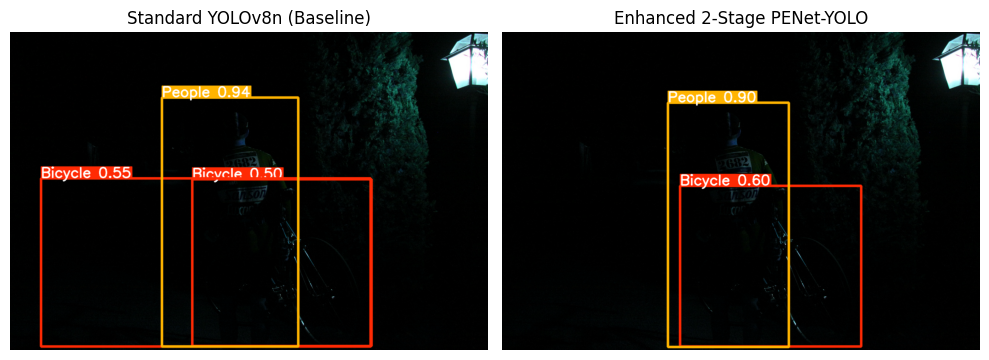

In [7]:

model = YOLO('/home/ai21ma3ai30/aaadi/runs/detect/runs/penet_stage2/end_to_end/weights/best.pt')
baseline=YOLO('/home/ai21ma3ai30/aaadi/runs/detect/runs/final_v8n/baseline/weights/best.pt')
results = model.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00301.jpg', conf=0.40, agnostic_nms=True)
results2 = baseline.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00301.jpg', conf=0.40, agnostic_nms=True)

%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(results2[0].plot())
axes[0].set_title("Standard YOLOv8n (Baseline)")
axes[0].axis('off')
axes[1].imshow(results[0].plot())
axes[1].set_title("Enhanced 2-Stage PENet-YOLO")
axes[1].axis('off')
plt.tight_layout()
plt.show()